In [1]:
import mysql.connector
from mysql.connector import errorcode
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
config = {    
  'user': 'root',
  'password': '*',  
  'host': 'localhost',
  'database': 'basketball_stats'
}

DB_NAME = 'basketball_stats' 

print("Connection parameters defined.")

Connection parameters defined.


In [3]:
try:
    
    cnxn = mysql.connector.connect(**config)
    cursor = cnxn.cursor()
    print("✅ Connected to basketball_stats database.")


    # cnxn.commit()
    # print("✅ SQL script executed successfully.")

except mysql.connector.Error as err:
    print(f"❌ Connection or execution error: {err}")

finally:
    if 'cnxn' in locals() and cnxn.is_connected():
        cursor.close()
        cnxn.close()
        print("✅ Connection closed.")

✅ Connected to basketball_stats database.
✅ Connection closed.


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در بخش اول توصیف آماری، در بررسی توزیع قد بازیکنان لیست جایزه مایکل جردن با 50 بازیکن برتر  در فصول 2019-2020 تا 2023-2024  موارد زیر مشاهده شد: 
</font>
</p>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در حالی که ۵۰ بازیکن برتر شامل تعداد زیادی بازیکن با قد متوسط هستند، بازیکنانی که به مرحله نامزدی MVP می‌رسند، اغلب بازیکنانی هستند با قد بلندتر 
</font>
</p>


<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در بخش دوم توصیف آماری، در بررسی توزیع قد و تجربه بازیکنان فعال در تیم قهرمان با 15 بازیکن برتر  در دو فصل آخر یعنی 2023-2024 و 2024-2025  موارد زیر مشاهده شد: 
</font>
</p>
<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
 ۱۵ بازیکن برتر  در فصول اخیر دارای قد نسبتا کوتاهتری نسبت به بازیکنان تیم‌های قهرمان هستند
</font>
</p>

<p dir=rtl style="direction: rtl;text-align: justify;line-height:200%;font-family:vazir;font-size:medium">
<font face="vazir" size=3>
در فصول اخیر، تیم‌های قهرمان تمایل داشته‌اند تا با استفاده از ترکیبی از بازیکنان کم تجربه تر و یک یا دو مهره‌ی باتجربه، به قهرمانی دست یابند، اما بازیکنان با تجربه بالا (بالای ۱۰ سال) سهم بسیار بزرگ‌تری از لیست 15 بازیکن برتر دو فصل اخیر دارند
</font>
</p>


In [4]:
#بخش اول
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query = """

        select
            mc.year as season,
            p.player_id,
            p.player_name,
            p.height_cm,
            'Michael Jordan Trophy' as group_label
        from mvp_candidates mc
        join players p on p.player_id = mc.player_id
        where mc.year between 2020 and 2024  and p.height_cm is not null

        union all

        
        select
            ps.season,
            p.player_id,
            p.player_name,
            p.height_cm,
            'Top 50 players' as group_label
        from player_stats ps
        join players p on p.player_id = ps.player_id
        where ps.season between 2020 and 2024
            and ps.rank <= 50 and p.height_cm is not null;
            """
        
        dataf1 = pd.read_sql(query, cnxn)
        

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")


C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_6820\1360909801.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataf1 = pd.read_sql(query, cnxn)


In [5]:
def hist_plot(columns_list:list[str], dataframe:pd.DataFrame, x,y)-> None:

    N= len(columns_list)
    rows = int(np.floor(np.sqrt(N)))
    cols= int(np.ceil(N/rows))
    fig, axes = plt.subplots(rows, cols, figsize = (x,y))

    if N==1:
        axes = [axes] 
    else:
        axes=axes.flatten()

    for i, col in enumerate (columns_list):
    
        sns.histplot(ax=axes[i], x=col, data=dataframe, kde=True, hue='group_label' , palette='Set1')

        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='y')
        axes[i].grid(axis='x', linestyle='--', linewidth=0.4, alpha=0.3)
        axes[i].tick_params(axis='both')
        sns.despine(ax=axes[i], top=True, right=True)
        

    fig.suptitle('histograms of Selected Columns', fontweight='bold')

    for j in range(N , len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [6]:
def kde_plot(columns_list: list[str], dataframe: pd.DataFrame, x: int, y: int) -> None:

    N = len(columns_list)
    rows = int(np.floor(np.sqrt(N)))
    cols = int(np.ceil(N / rows))
    fig, axes = plt.subplots(rows, cols, figsize=(x, y))

    if N == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(columns_list):
        sns.kdeplot(ax=axes[i], data=dataframe, x=col,hue='group_label', palette='Set1',fill=True,common_norm=True)
       
        axes[i].set_title(f'{col}')
        axes[i].set_ylabel('')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='y')
        axes[i].grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.3)
        axes[i].tick_params(axis='both')
        sns.despine(ax=axes[i], top=True, right=True)

    fig.suptitle(f"Distribution of: {', '.join(columns_list)} by group", fontweight='bold')
    
    for j in range(N, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


In [7]:
def box_plot(columns_list:list[str], dataframe:pd.DataFrame, fig_x:float, fig_y:float)->None:
    
    N= len(columns_list)
    rows = int(np.floor(np.sqrt(N)))
    cols= int(np.ceil(N/rows))
    fig, axes = plt.subplots(rows, cols, figsize = (fig_x,fig_y))

    if N==1:
        axes = [axes] 
    else:
        axes=axes.flatten()

    for i, col in enumerate(columns_list):
        sns.boxplot(ax=axes[i], data=dataframe, x='group_label',y=col, palette='Pastel1')
        axes[i].set_title('')
        axes[i].set_ylabel('')
        axes[i].set_xlabel(f'{col}')
        axes[i].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.3)
        axes[i].tick_params(axis='both')
        sns.despine(ax=axes[i], top=True, right=True)
        
    for j in range(N , len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

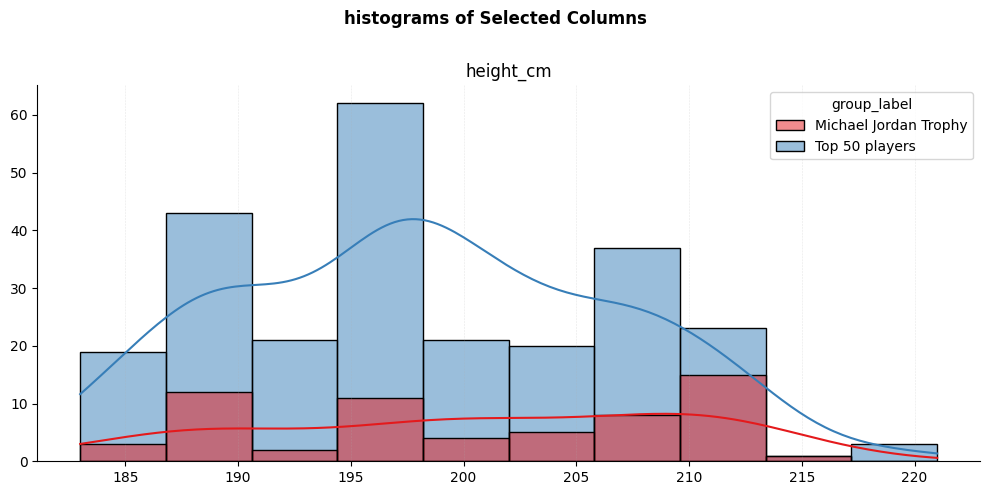

In [8]:
hist_plot( columns_list=['height_cm'], dataframe= dataf1,  x=10,  y=5 )

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

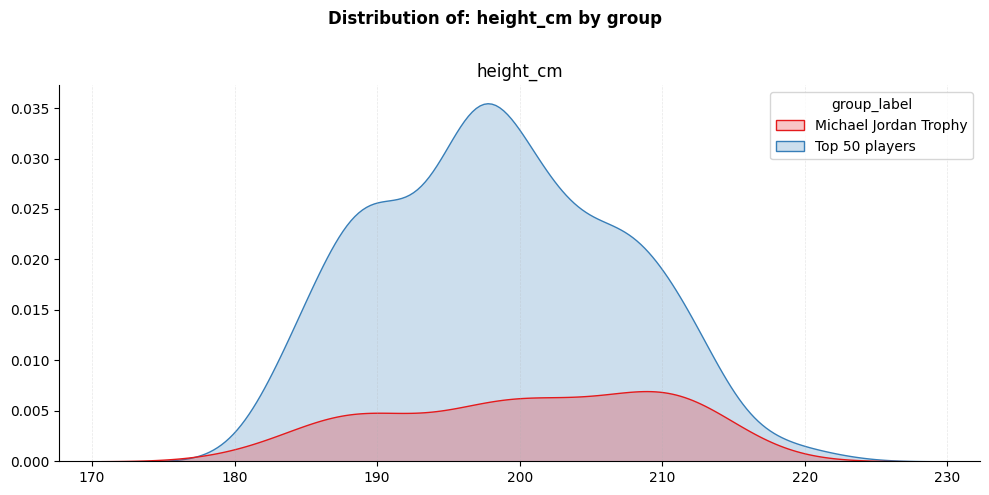

In [9]:
kde_plot(['height_cm'], dataf1, x=10, y=5)

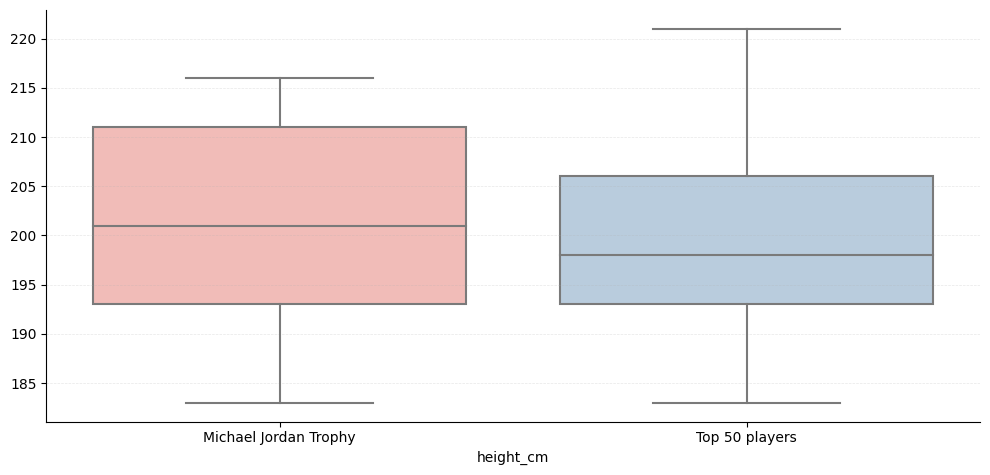

In [10]:
box_plot(['height_cm'], dataf1, fig_x=10, fig_y=5)

In [11]:
# بخش دوم 
try:
    
    with mysql.connector.connect(**config) as cnxn:
        query = """
        with top15 as (
            select
                ps.player_id,
                ps.season,
                ps.rank,
                row_number() over (partition by ps.season order by  ps.rank asc) as rn
            from player_stats ps
            where ps.season in (2024, 2025) and ps.rank is not null
    )

        select
            r.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm,
            'Champion team players' as group_label
        from season_stats s
        join team_lookup t on s.champion_name = t.team_name
        join rosters r on r.team_id = t.team_id and r.season = s.season
        join players p on p.player_id = r.player_id
        where s.season in (2024,2025)
            and p.experience is not null
            and p.height_cm is not null

        union all

        select
            ps.season,
            p.player_id,
            p.player_name,
            p.experience,
            p.height_cm,
            'Top 15 players' as group_label
        from top15
        join player_stats ps on ps.player_id = top15.player_id and ps.season = top15.season
        join players p on p.player_id = top15.player_id
        where top15.rn <= 15 
            and p.experience is not null and p.height_cm is not null;

        """
        
        dataf2 = pd.read_sql(query, cnxn)
        display(dataf2)

except mysql.connector.Error as err:
    print(f"❌ Error: {err}")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_6820\3858235855.py:48: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dataf2 = pd.read_sql(query, cnxn)


,season,player_id,player_name,experience,height_cm,group_label
0,2024,bantoda01,dalano banton,4.0,206.0,Champion team players
1,2024,brissos01,oshae brissett,6.0,201.0,Champion team players
2,2024,brownja02,jaylen brown,9.0,198.0,Champion team players
3,2024,davisjd01,jd davison,3.0,185.0,Champion team players
4,2024,hausesa01,sam hauser,4.0,203.0,Champion team players
...,...,...,...,...,...,...
63,2025,townska01,karl-anthony towns,10.0,213.0,Top 15 players
64,2025,lavinza01,zach lavine,11.0,196.0,Top 15 players
65,2025,greenja05,jalen green,4.0,193.0,Top 15 players
66,2025,curryst01,stephen curry,16.0,188.0,Top 15 players


c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

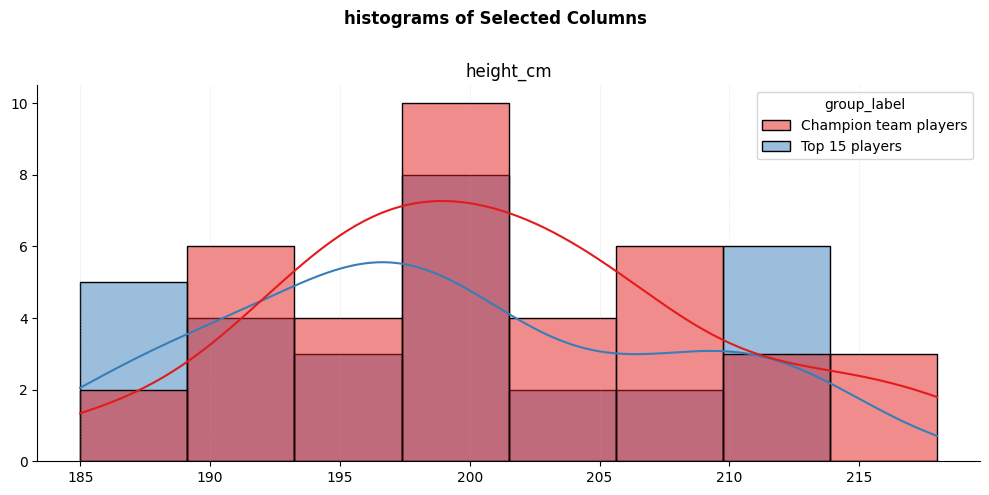

In [12]:
hist_plot( columns_list=['height_cm'], dataframe=  dataf2,  x=10,  y=5 )

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

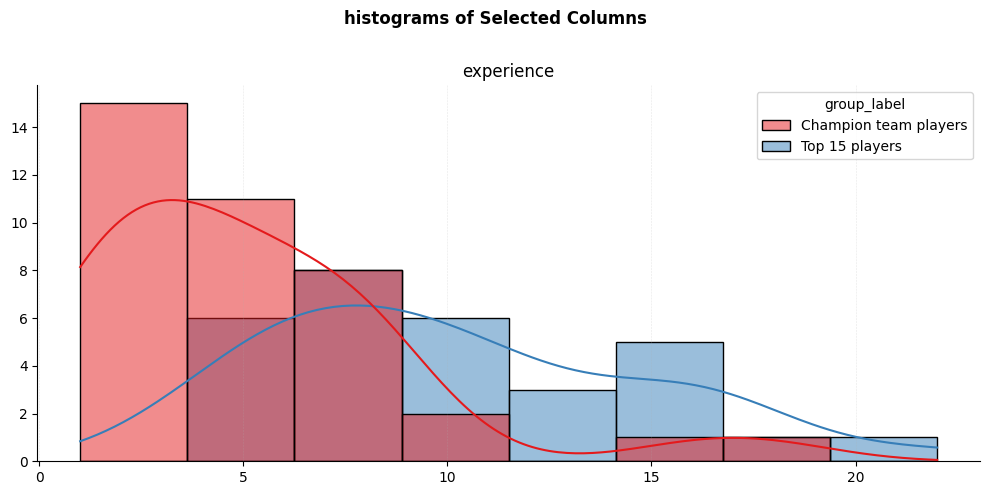

In [13]:
hist_plot( columns_list=['experience'], dataframe=  dataf2,  x=10,  y=5 )

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

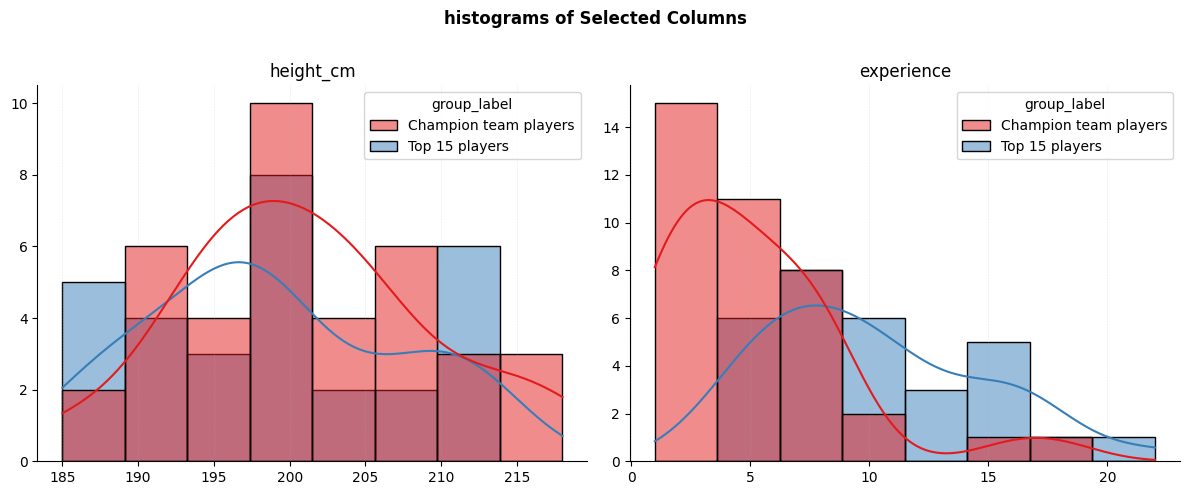

In [14]:
hist_plot( columns_list=['height_cm','experience'], dataframe=  dataf2,  x=12,  y=5 )

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

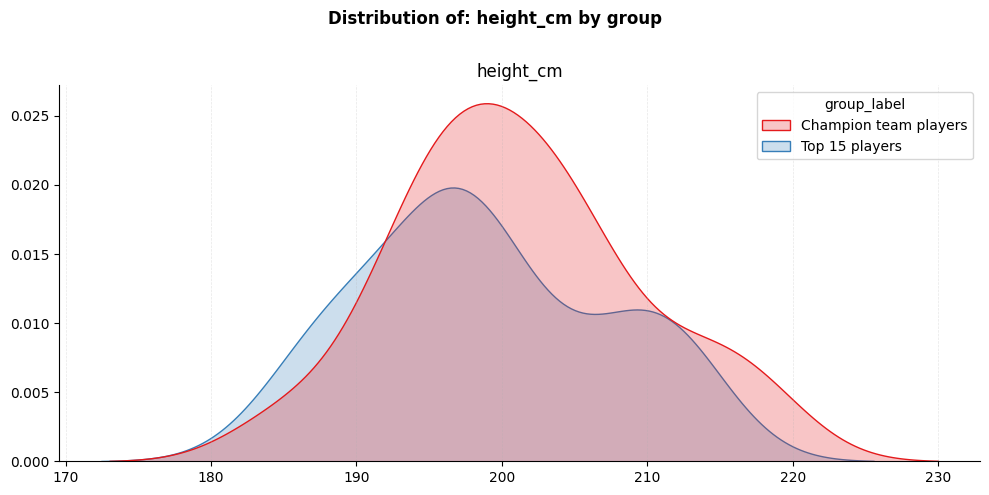

In [15]:
kde_plot(['height_cm'], dataf2, x=10, y=5)

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

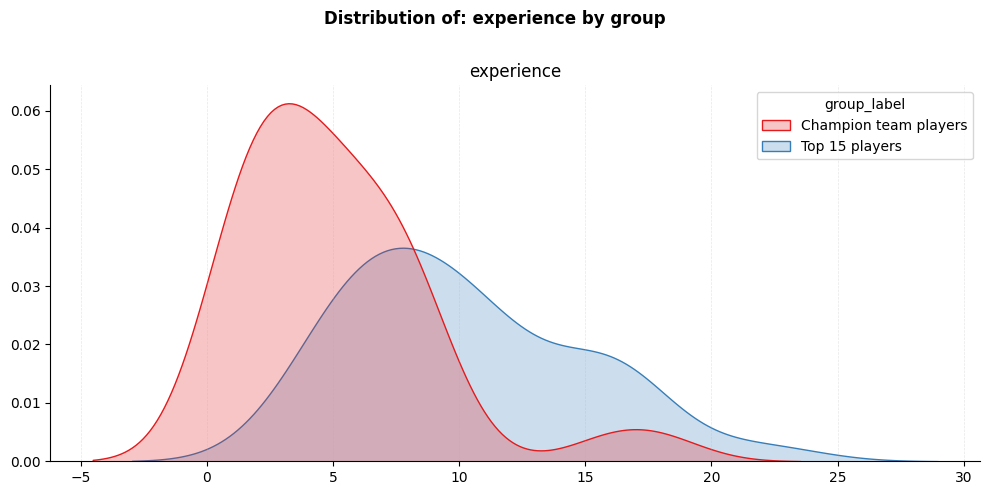

In [16]:
kde_plot(['experience'], dataf2, x=10, y=5)

c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\Zagros\miniconda3\envs\quera\lib\site-packages\seaborn\_oldc

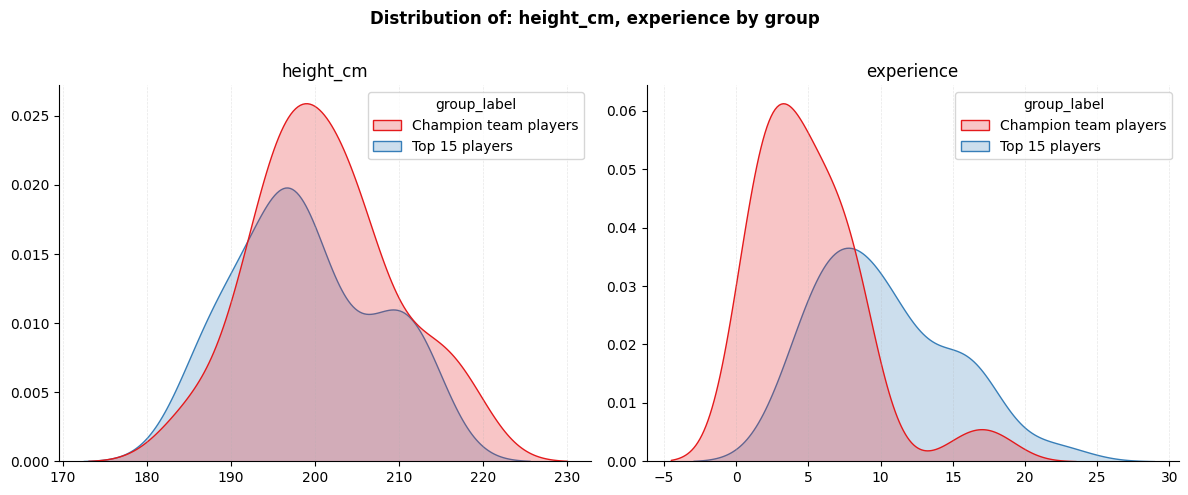

In [17]:
kde_plot(['height_cm', 'experience'], dataf2, x=12, y=5)

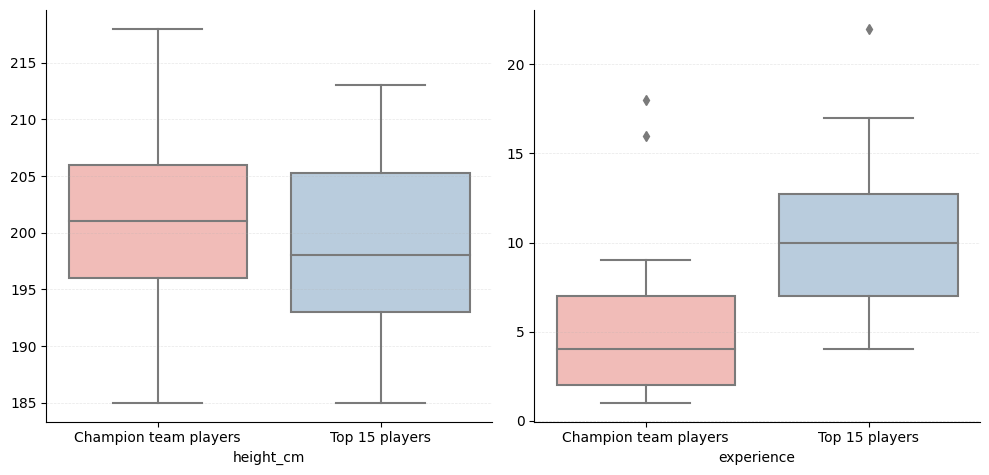

In [18]:
box_plot(['height_cm', 'experience'], dataf2, fig_x=10, fig_y=5)